# Step 1: Dataset Loading & Exploratory Data Analysis

## 1.1  Load & Inspect the Dataset

In [46]:
# Load CC_GENERAL.csv. Print .shape, .info(), and .head(10).

import pandas as pd
import numpy as np

df = pd.read_csv("CC GENERAL.csv")

df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


In [47]:
print("Dataset Shape:", df.shape)

Dataset Shape: (8950, 18)


In [48]:
print("Dataset Info:", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [49]:
# Drop the CUST_ID column (unique identifier, not a feature).
df = df.drop("CUST_ID", axis=1)

print("Updated Shape:", df.shape)

Updated Shape: (8950, 17)


CUST_ID is a unique identifier and does not contribute to clustering, so it was removed.

In [50]:
#  Report how many missing values exist in each column.
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


In [51]:
# Impute missing CREDIT_LIMIT with the column median, and missing MINIMUM_PAYMENTS with the column median. Report how many values were imputed.
credit_limit_missing = df["CREDIT_LIMIT"].isnull().sum()
minimum_payment_missing = df["MINIMUM_PAYMENTS"].isnull().sum()

df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

print("CREDIT_LIMIT values imputed :", credit_limit_missing)
print("MINIMUM_PAYMENTS values imputed :", minimum_payment_missing)

CREDIT_LIMIT values imputed : 1
MINIMUM_PAYMENTS values imputed : 313


In [52]:
print(df.isnull().sum())

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


Missing values were replaced with the median because it is robust to outliers and preserves the data distribution.

In [53]:
# Check for and report duplicate rows.
duplicate_rows = df.duplicated().sum()


print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


## 1.2  Univariate Analysis

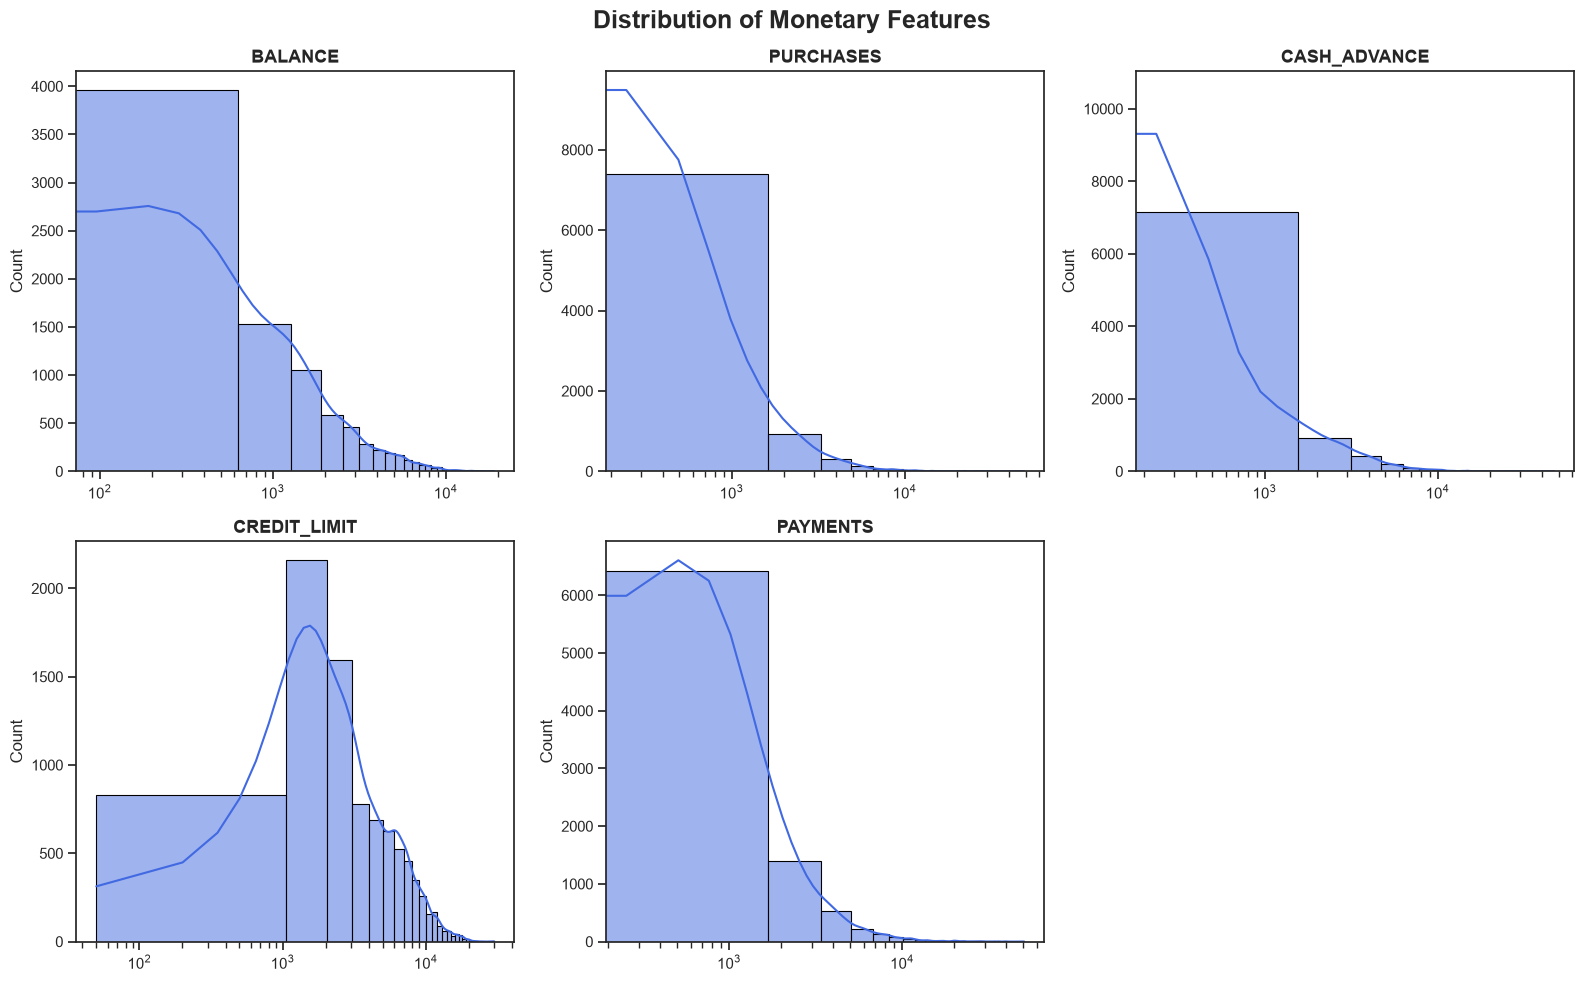

In [54]:
# Plot histograms for: BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS (log-scale the x-axis for readability).

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

fig, axes = plt.subplots(2, 3, figsize=(16,10))
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i],
        color="royalblue",
        edgecolor="black"
    )

    axes[i].set_xscale("log")
    axes[i].set_title(col, fontsize=13, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Distribution of Monetary Features", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

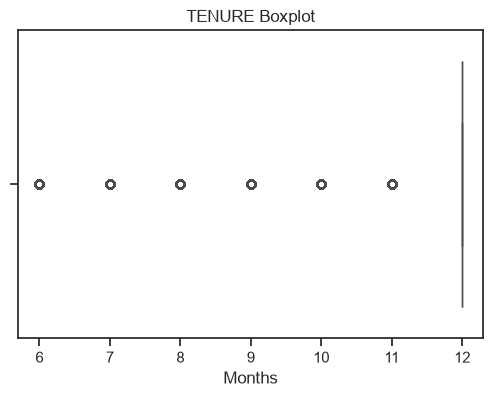

In [55]:
# Plot a boxplot of TENURE (months as a cardholder) to see how long customers have held their cards.

plt.figure(figsize=(6,4))

sns.boxplot(x=df["TENURE"])

plt.title("TENURE Boxplot")
plt.xlabel("Months")

plt.show()

Most customers have held their credit cards for a similar duration, with only a few extreme values.

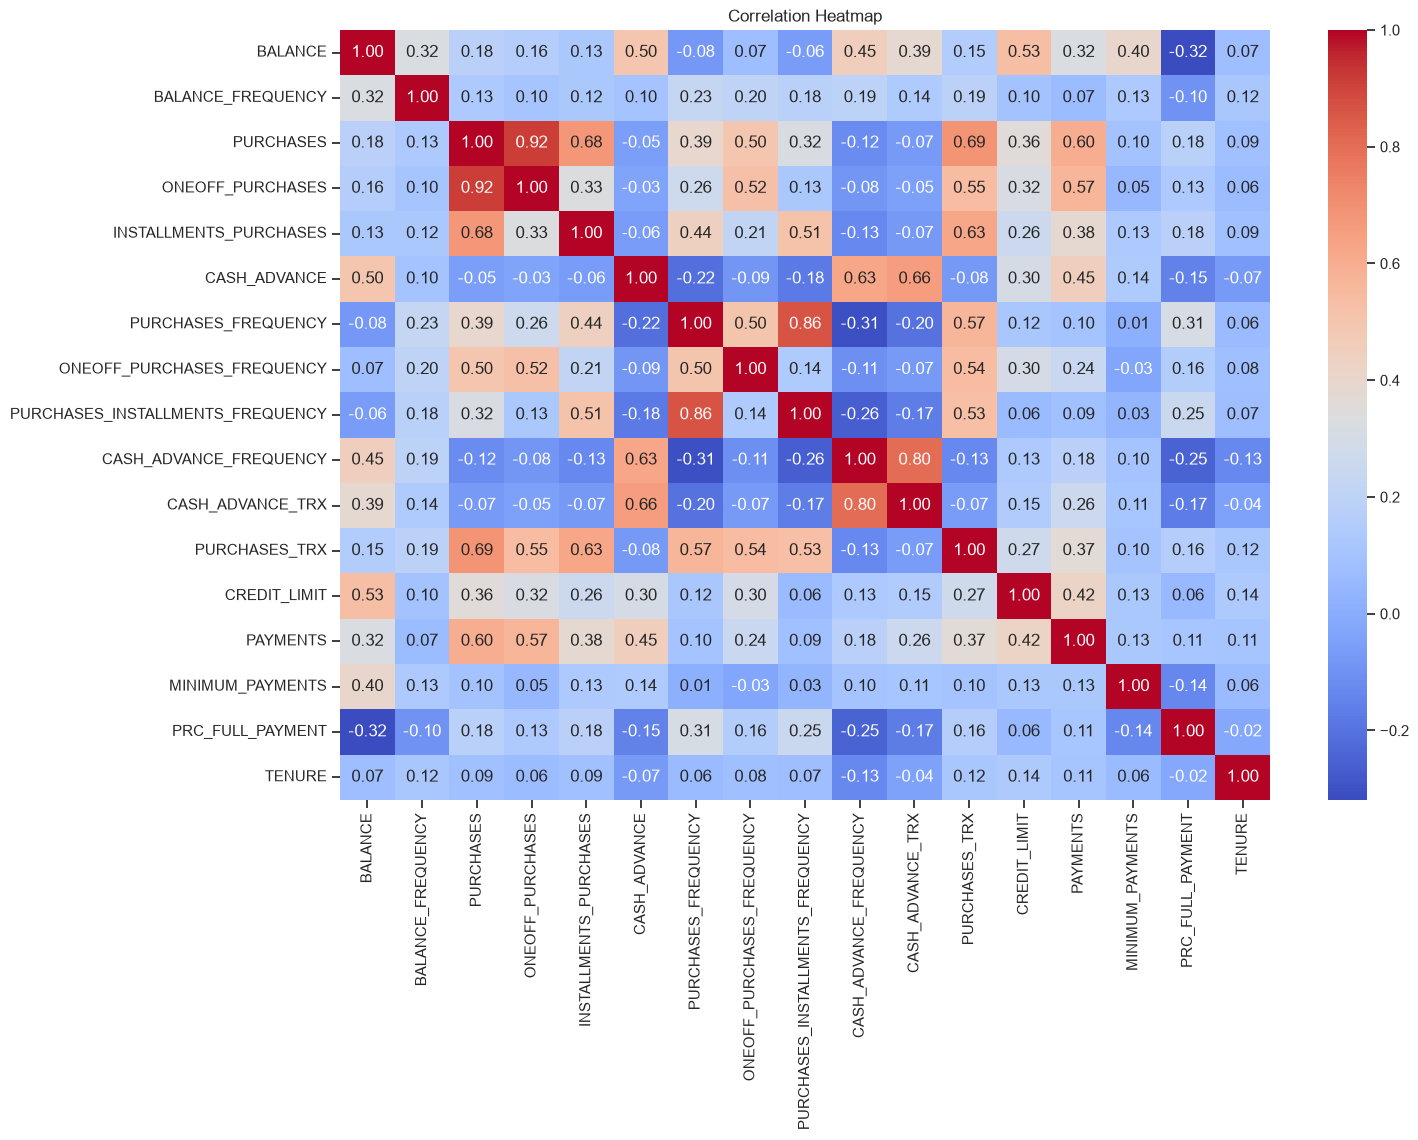

In [56]:
# Plot a correlation heatmap of all 17 numeric features. Which features are highly correlated?

plt.figure(figsize=(15,10))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

## 1.3  Customer-Level Analysis

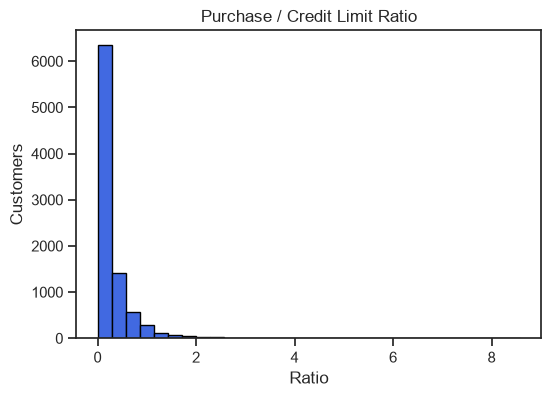

In [57]:
# Compute the ratio PURCHASES / CREDIT_LIMIT for each customer as a rough utilisation measure. Plot its distribution.
df["Purchase_Credit_Ratio"] = df["PURCHASES"] / (df["CREDIT_LIMIT"] + 1)

plt.figure(figsize=(6,4))

plt.hist(df["Purchase_Credit_Ratio"],
         bins=30,
         color="royalblue",
         edgecolor="black")

plt.title("Purchase / Credit Limit Ratio")

plt.xlabel("Ratio")

plt.ylabel("Customers")

plt.show()

Most customers use only a small portion of their available credit limit for purchases.

In [58]:
#  Who are the top 10 customers by CASH_ADVANCE? Are they also high PURCHASES customers, or a distinct group?
top10 = df.sort_values(by="CASH_ADVANCE", ascending=False).head(10)

top10[["CASH_ADVANCE","PURCHASES"]]

,CASH_ADVANCE,PURCHASES
2159,47137.21176,431.93
1059,29282.10915,3719.00
71,27296.48576,4523.27
7254,26268.69989,1750.66
7645,26194.04954,0.00
2454,23130.82106,0.00
883,22665.77850,0.00
6371,21943.84942,0.00
3806,20712.67008,4995.80
6455,20277.33112,1490.75


These customers have the highest cash advances. Compare their PURCHASES values to determine whether they are also high-spending customers or belong to a different customer group.

In [59]:
# Report: what % of customers have never made a purchase (PURCHASES == 0)?

never_purchase = (df["PURCHASES"] == 0).sum()

percentage = (never_purchase / len(df)) * 100

print("Customers with PURCHASES = 0 :", never_purchase)
print(f"Percentage : {percentage:.2f}%")

Customers with PURCHASES = 0 : 2044
Percentage : 22.84%


This shows the percentage of customers who have never used their credit card for purchases.

In [60]:
purchase_sorted = df["PURCHASES"].sort_values(ascending=False)

cumulative = purchase_sorted.cumsum()

total_purchase = purchase_sorted.sum()

percentage_purchase = cumulative / total_purchase

customers_needed = (percentage_purchase <= 0.80).sum()

customer_percent = (customers_needed / len(df)) * 100

print(f"{customer_percent:.2f}% of customers contribute nearly 80% of total purchases.")

26.20% of customers contribute nearly 80% of total purchases.


This analysis checks whether a small percentage of customers contribute to most of the purchase volume, following the Pareto (80–20) principle.

# Step 2: Feature Engineering & Preprocessing

## 2.1  Engineer Behavioural Features

In [61]:
# Monthly_Avg_Purchase: PURCHASES / TENURE

df["Monthly_Avg_Purchase"] = df["PURCHASES"] / df["TENURE"]

In [62]:
# Monthly_Avg_Cash_Advance: CASH_ADVANCE / TENURE. 

df["Monthly_Avg_Cash_Advance"] = df["CASH_ADVANCE"] / df["TENURE"]


In [63]:
# Limit_Usage: BALANCE / CREDIT_LIMIT (guard against divide-by-zero).

df["Limit_Usage"] = df["BALANCE"] / (df["CREDIT_LIMIT"] + 1)

In [64]:
#  Payment_to_Minpayment_Ratio: PAYMENTS / (MINIMUM_PAYMENTS + 1).

df["Payment_to_Minpayment_Ratio"] = df["PAYMENTS"] / (df["MINIMUM_PAYMENTS"] + 1)


In [65]:
# Print the resulting feature-engineered DataFrame — one row per customer — and .describe() on the new columns. Note the range and skewness of each.

engineered_cols = [
    "Monthly_Avg_Purchase",
    "Monthly_Avg_Cash_Advance",
    "Limit_Usage",
    "Payment_to_Minpayment_Ratio"
]

display(df[engineered_cols].head())

desc = df[engineered_cols].describe()
skew = df[engineered_cols].skew().rename("skew")
display(desc)
display(skew)

,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,7.950000,0.000000,0.040860,1.436214
1,0.000000,536.912124,0.457430,3.822677
2,64.430833,0.000000,0.332642,0.990103
3,124.916667,17.149001,0.222193,0.000000
4,1.333333,0.000000,0.680861,2.759800


,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
count,8950.000000,8950.000000,8950.000000,8950.000000
mean,86.175173,88.977984,0.388663,6.390555
std,180.508787,193.136115,0.388162,31.995344
min,0.000000,0.000000,0.000000,0.000000
25%,3.399375,0.000000,0.041485,0.910572
50%,31.936667,0.000000,0.302493,2.016643
75%,97.228333,99.085196,0.717229,6.013980
max,4086.630833,3928.100980,15.597991,1863.850036


Monthly_Avg_Purchase            8.004530
Monthly_Avg_Cash_Advance        4.944361
Limit_Usage                     7.083895
Payment_to_Minpayment_Ratio    36.902249
Name: skew, dtype: float64

## 2.2  Handle Outliers

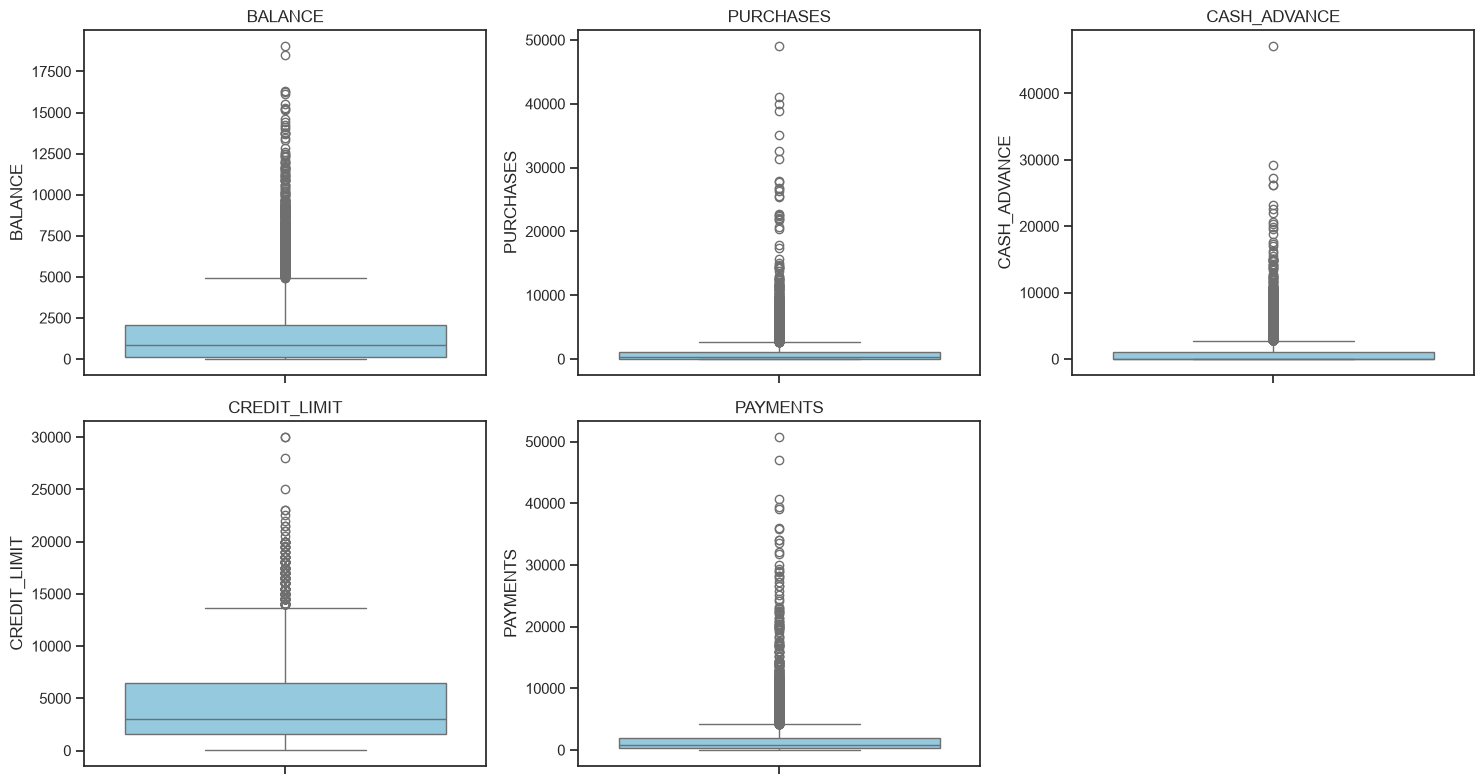

In [66]:
# Plot boxplots for BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, and PAYMENTS. Identify extreme outliers.

cols = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]

plt.figure(figsize=(15,8))

for i, col in enumerate(cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

The boxplots indicate the presence of several extreme outliers in monetary features.

In [67]:
# Cap outliers using the IQR method: for each column, cap values above Q3 + 3×IQR to that threshold (winsorization — do not drop rows).


df_outlier = df.copy()

caps = {}  

for col in cols:
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3 - Q1

    upper_limit = Q3 + (3 * IQR)
    caps[col] = upper_limit

    df_outlier[col] = df_outlier[col].clip(upper=upper_limit)

print("Learned cap thresholds (Q3 + 3*IQR):")
print(caps)

Learned cap thresholds (Q3 + 3*IQR):
{'BALANCE': np.float64(7831.714395500001), 'PURCHASES': np.float64(4321.615000000001), 'CASH_ADVANCE': np.float64(4455.284557000001), 'CREDIT_LIMIT': np.float64(21200.0), 'PAYMENTS': np.float64(6454.708769000001)}


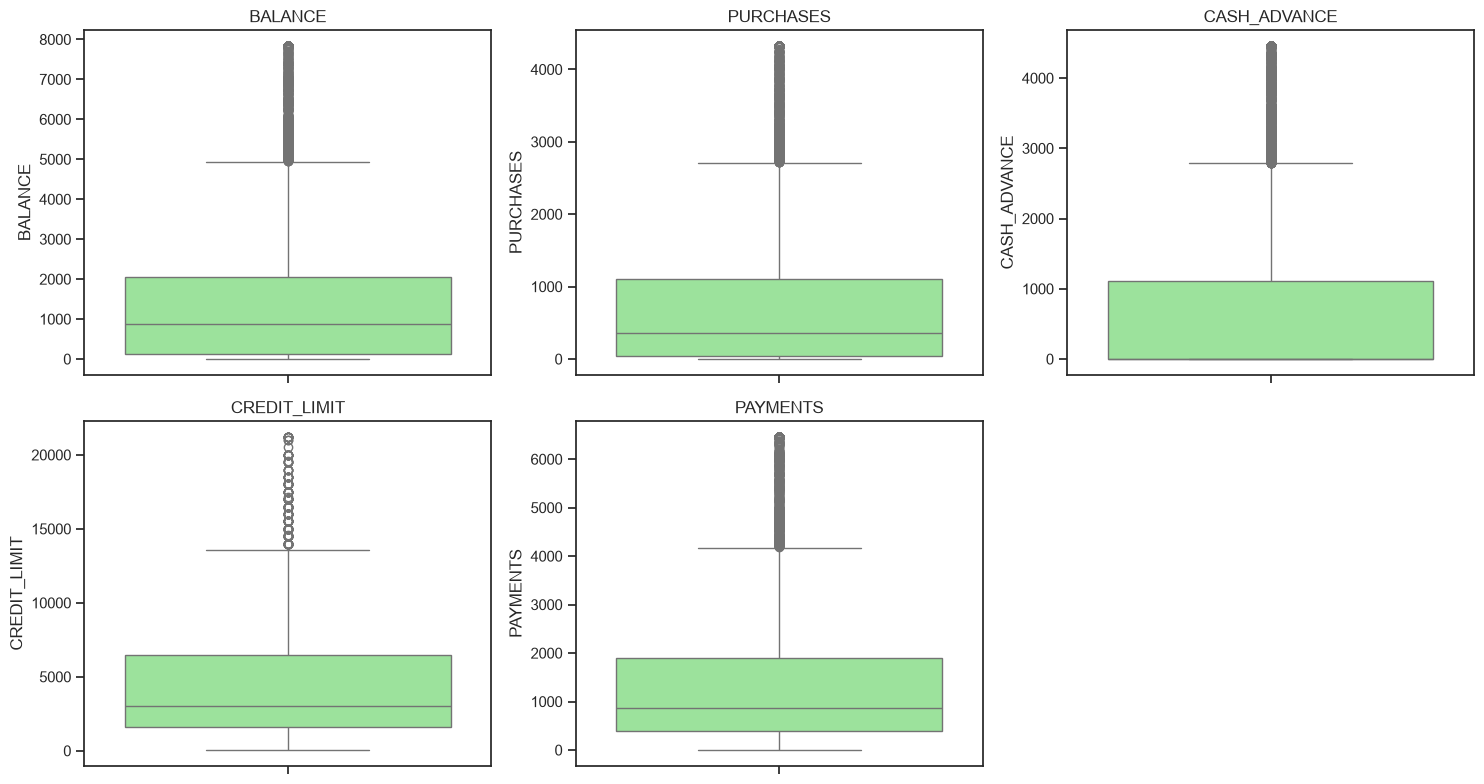

In [68]:
# Re-plot boxplots after capping to confirm outliers are handled.

plt.figure(figsize=(15,8))

for i, col in enumerate(cols):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df_outlier[col], color="lightgreen")
    plt.title(col)

plt.tight_layout()
plt.show()

## 2.3  Transform Skewed Features

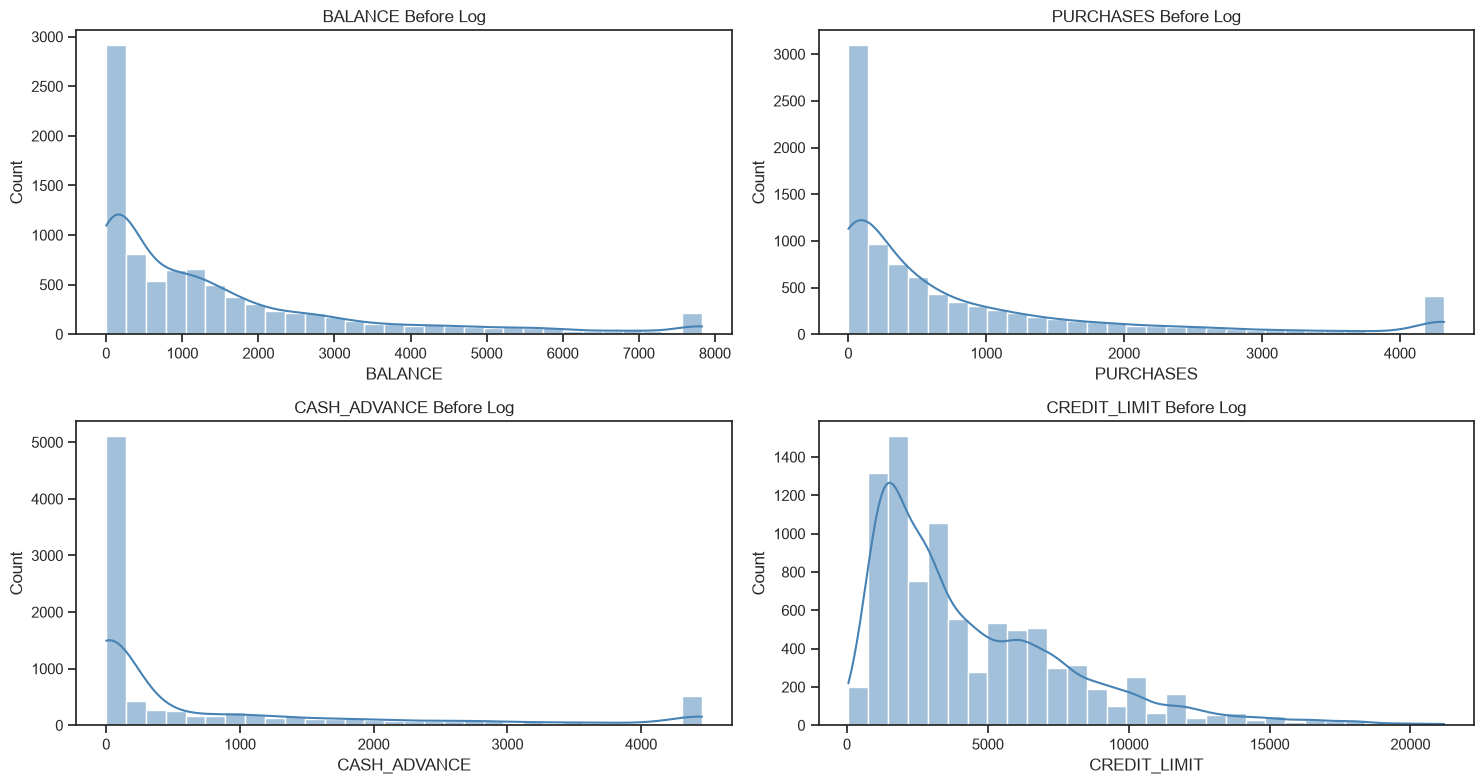

In [69]:
# Plot histograms of BALANCE, PURCHASES, CASH_ADVANCE, and CREDIT_LIMIT before transformation.
plt.figure(figsize=(15,8))

for i, col in enumerate(cols[:4]):
    plt.subplot(2,2,i+1)

    sns.histplot(df_outlier[col],
                 bins=30,
                 kde=True,
                 color="steelblue")

    plt.title(f"{col} Before Log")

plt.tight_layout()
plt.show()

The distributions are right-skewed, with many low values and a few very high values.

In [70]:
# Apply log1p transformation to all monetary columns (they are typically right-skewed).
log_columns = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT"]

for col in log_columns:
    df_outlier[col] = np.log1p(df_outlier[col])


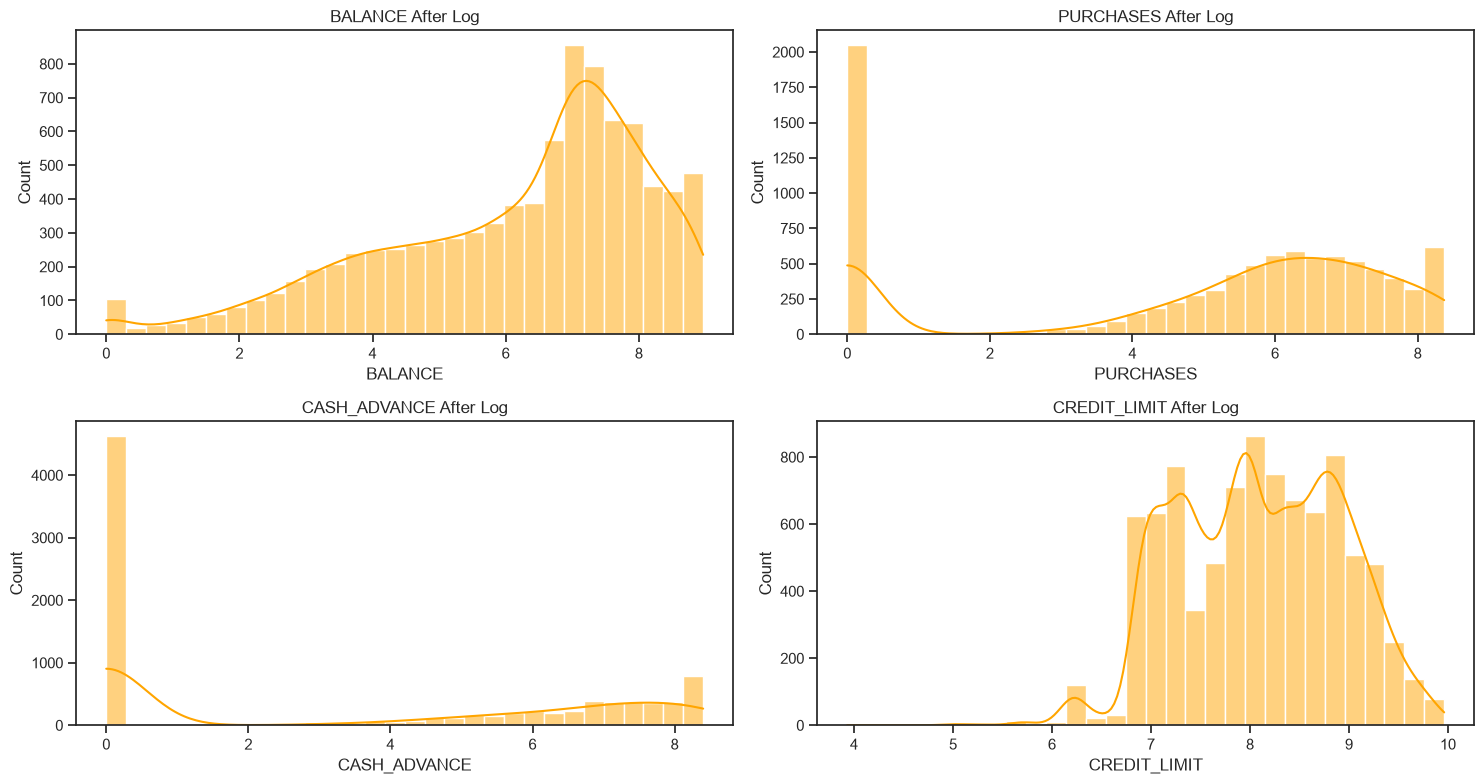

In [71]:
# Re-plot histograms after transformation. Are the distributions more symmetrical?
plt.figure(figsize=(15,8))

for i, col in enumerate(log_columns):
    plt.subplot(2,2,i+1)

    sns.histplot(df_outlier[col],
                 bins=30,
                 kde=True,
                 color="orange")

    plt.title(f"{col} After Log")

plt.tight_layout()
plt.show()

After the log transformation, the distributions become more symmetric, which is beneficial for clustering algorithms.

## 2.4  Scale the Features

In [72]:
# Apply StandardScaler to the full set of engineered + transformed features.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cc_scaled = scaler.fit_transform(df_outlier)

In [73]:
# Store the scaled features as cc_scaled (a numpy array or DataFrame).
cc_scaled = pd.DataFrame(cc_scaled, columns=df_outlier.columns)

cc_scaled.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Purchase_Credit_Ratio,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,-1.207143,-0.249434,-0.107336,-0.356934,-0.349079,-0.933764,-0.806490,-0.678661,-0.707313,-0.675349,...,-1.447653,-0.782590,-0.302400,-0.525551,0.36068,-0.383194,-0.433384,-0.460727,-0.896075,-0.154854
1,0.954731,0.134325,-1.689286,-0.356934,-0.454576,1.447518,-1.221758,-0.678661,-0.916995,0.573963,...,0.926693,1.580002,0.097500,0.234227,0.36068,-0.601672,-0.477428,2.319396,0.177171,-0.080262
2,0.830361,0.518084,0.614049,0.108889,-0.454576,-0.933764,1.269843,2.673451,-0.916995,-0.675349,...,1.010901,-0.528077,-0.093293,-0.525551,0.36068,-0.365380,-0.120468,-0.460727,-0.144331,-0.168798
3,0.629302,-1.016953,0.843084,0.546189,-0.454576,0.577324,-1.014125,-0.399319,-0.916995,-0.258913,...,1.010901,-0.904802,-0.228307,-0.525551,0.36068,-0.143555,0.214636,-0.371929,-0.428890,-0.199745
4,0.274639,0.518084,-0.708221,-0.347294,-0.454576,-0.933764,-1.014125,-0.399319,-0.916995,-0.675349,...,-1.225295,-0.494001,-0.257266,-0.525551,0.36068,-0.571132,-0.470041,-0.460727,0.752817,-0.113484


In [74]:
# Optionally apply PCA (retain 90–95% variance) to reduce dimensionality before clustering; report how many components were kept.
from sklearn.decomposition import PCA

# Keep 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

cc_pca = pca.fit_transform(cc_scaled)

print("Original Features :", cc_scaled.shape[1])
print("Components Kept   :", cc_pca.shape[1])
print("Explained Variance:", pca.explained_variance_ratio_.sum())

Original Features : 22
Components Kept   : 15
Explained Variance: 0.9528675239074935


In [75]:
# Print the mean and standard deviation of each scaled feature to confirm scaling worked (mean ≈ 0, std ≈ 1).
scaled_summary = pd.DataFrame({
    "Mean": cc_scaled.mean(),
    "Std Dev": cc_scaled.std()
})

scaled_summary

,Mean,Std Dev
BALANCE,1.397268e-16,1.000056
BALANCE_FREQUENCY,2.286439e-16,1.000056
PURCHASES,-1.206732e-16,1.000056
ONEOFF_PURCHASES,3.175610e-17,1.000056
INSTALLMENTS_PURCHASES,2.540488e-17,1.000056
CASH_ADVANCE,8.256586e-17,1.000056
PURCHASES_FREQUENCY,-1.841854e-16,1.000056
ONEOFF_PURCHASES_FREQUENCY,-8.891708e-17,1.000056
PURCHASES_INSTALLMENTS_FREQUENCY,4.604634e-17,1.000056
CASH_ADVANCE_FREQUENCY,5.557317e-17,1.000056


The scaled features have a mean close to 0 and a standard deviation close to 1, confirming that scaling was successful.

# Step 3: K-Means Clustering

## 3.1  Elbow Method — Find Optimal k

In [76]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
# Run KMeans for k = 2, 3, 4, 5, 6, 7, 8, 9, 10 (use init='k-means++', n_init=10, random_state=42).
k_values = range(2, 11)

inertia = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    labels = kmeans.fit_predict(cc_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(cc_scaled, labels))

c:\Users\Meet Anghan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Meet Anghan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\Meet Anghan\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Meet Anghan\AppData\Loc

K-Means models were trained for k = 2 to 10. For each model, the Within-Cluster Sum of Squares (Inertia) and Silhouette Score were calculated.

In [78]:
# For each k, compute and store: Within-Cluster Sum of Squares (inertia_).
results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

results

,K,Inertia,Silhouette Score
0,2,162403.271847,0.202349
1,3,141714.601254,0.203473
2,4,130963.221612,0.186665
3,5,121724.177267,0.181047
4,6,115185.791164,0.167115
5,7,108755.392564,0.165652
6,8,104735.941989,0.169029
7,9,99114.726039,0.169792
8,10,96287.405890,0.162201


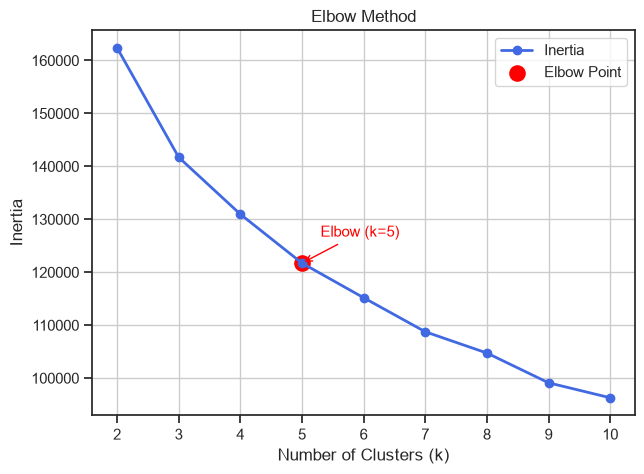

In [79]:
# Plot the Elbow Curve (k vs Inertia). Mark the elbow point visually.

plt.figure(figsize=(7,5))

plt.plot(k_values, inertia,
         marker='o',
         linewidth=2,
         color='royalblue',
         label='Inertia')

# Elbow point (change if you choose another k)
elbow_k = 5
elbow_inertia = inertia[elbow_k - 2]   # Because k starts from 2

plt.scatter(elbow_k,
            elbow_inertia,
            color='red',
            s=120,
            label='Elbow Point')

plt.annotate(f'Elbow (k={elbow_k})',
             xy=(elbow_k, elbow_inertia),
             xytext=(elbow_k+0.3, elbow_inertia+5000),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=11,
             color='red')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.legend()

plt.show()

The Elbow Curve helps identify the point where adding more clusters results in only a small reduction in inertia.

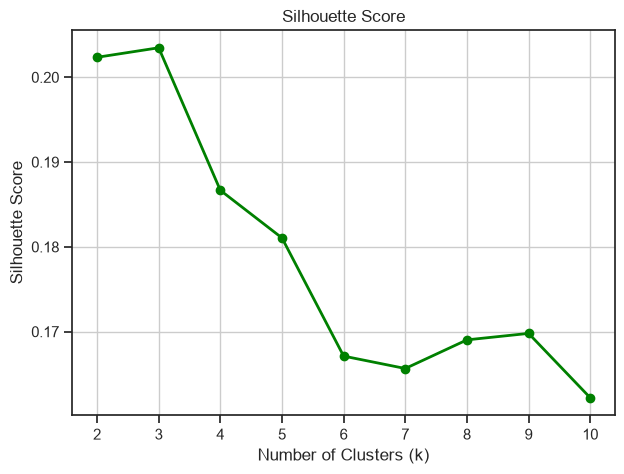

In [80]:
# Compute Silhouette Score for each k. Plot k vs Silhouette Score. Which k gives the highest Silhouette Score?
plt.figure(figsize=(7,5))

plt.plot(k_values,
         silhouette_scores,
         marker="o",
         linewidth=2,
         color="green")

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

The Silhouette Score measures cluster quality. A higher score indicates better-separated and more compact clusters.

In [81]:
# Based on both plots, choose your optimal k. Justify your choice in 2–3 sentences.
best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "K"
]

print("Best K based on Silhouette Score:", best_k)

Best K based on Silhouette Score: 3


The Elbow Curve shows the inertia flattening out noticeably from **k = 4** onward, with only marginal improvement beyond **k = 5**. The Silhouette Score is actually maximised at **k = 3** (≈0.203), slightly ahead of k = 5 (≈0.181). However, k = 3 produces very broad, less actionable segments for the business, while **k = 5** still scores well on Silhouette, aligns with the elbow bend, and yields five distinctly interpretable cardholder personas. We therefore select **k = 5** as the optimal number of clusters, prioritising business interpretability over the single highest metric value.

## 3.2  Train Final K-Means Model

In [82]:
# Train KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=42).

k_optimal = 5

kmeans = KMeans(
    n_clusters=k_optimal,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

kmeans.fit(cc_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",500
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [83]:
# Assign cluster labels back to the original (unscaled) feature DataFrame as a new column: KMeans_Cluster.
df["KMeans_Cluster"] = kmeans.labels_

df[["KMeans_Cluster"]].head()

,KMeans_Cluster
0,2
1,4
2,0
3,1
4,1


The K-Means model was trained using 5 clusters, and each customer was assigned to a cluster based on similar behavioural patterns.

In [84]:
df["KMeans_Cluster"].value_counts().sort_index()

KMeans_Cluster
0    3294
1    2596
2    1485
3     547
4    1028
Name: count, dtype: int64

## 3.3  Visualise K-Means Clusters

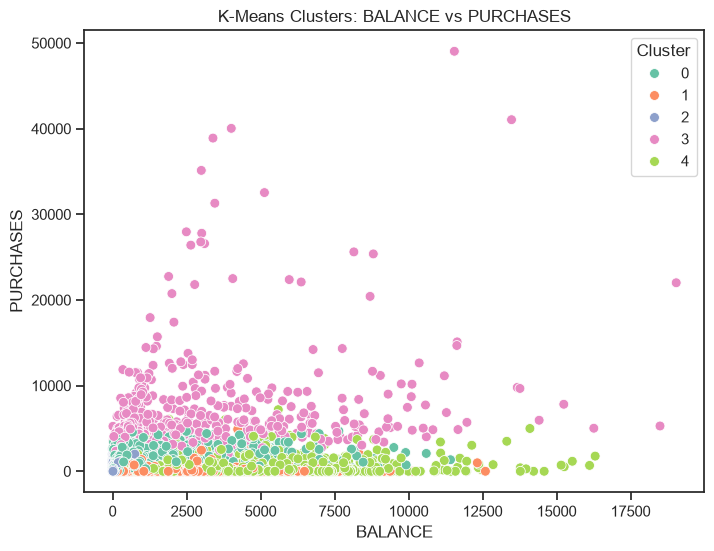

In [85]:
# 2D Scatter plot: BALANCE vs PURCHASES, coloured by KMeans_Cluster. Add a legend
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="BALANCE",
    y="PURCHASES",
    hue="KMeans_Cluster",
    palette="Set2",
    s=50
)

plt.title("K-Means Clusters: BALANCE vs PURCHASES")
plt.legend(title="Cluster")
plt.show()

Customers are grouped into different clusters based on their balance and purchase behaviour.

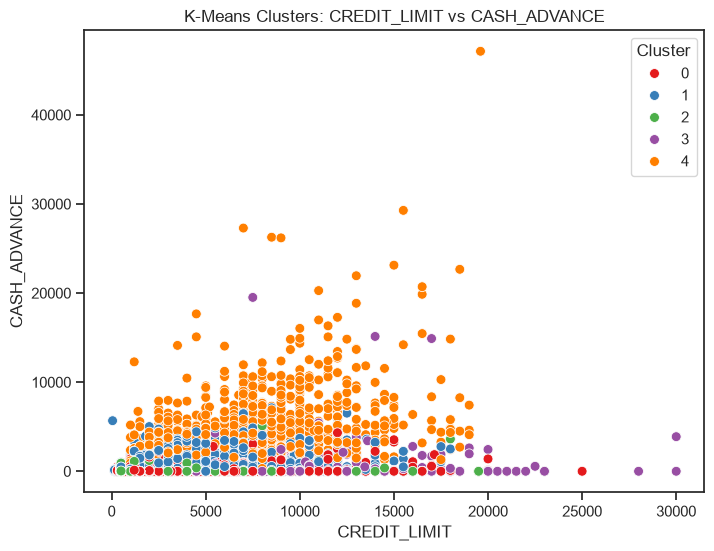

In [86]:
# 2D Scatter plot: CREDIT_LIMIT vs CASH_ADVANCE, coloured by KMeans_Cluster.
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="CREDIT_LIMIT",
    y="CASH_ADVANCE",
    hue="KMeans_Cluster",
    palette="Set1",
    s=50
)

plt.title("K-Means Clusters: CREDIT_LIMIT vs CASH_ADVANCE")
plt.legend(title="Cluster")
plt.show()

The clusters represent different credit limit and cash advance usage patterns.

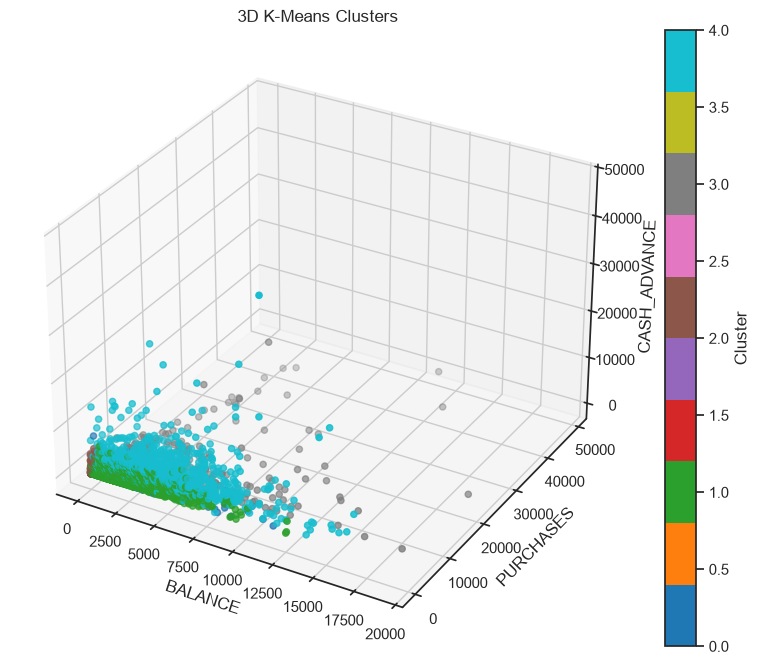

In [87]:
# 3D Scatter plot (matplotlib or plotly): BALANCE vs PURCHASES vs CASH_ADVANCE, coloured by cluster. This is the key visual — spend time making it readable.
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["BALANCE"],
    df["PURCHASES"],
    df["CASH_ADVANCE"],
    c=df["KMeans_Cluster"],
    cmap="tab10",
    s=20
)

ax.set_xlabel("BALANCE")
ax.set_ylabel("PURCHASES")
ax.set_zlabel("CASH_ADVANCE")

plt.title("3D K-Means Clusters")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [88]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x="BALANCE",
    y="PURCHASES",
    z="CASH_ADVANCE",
    color=df["KMeans_Cluster"].astype(str),
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="3D K-Means Customer Clusters",
    labels={
        "BALANCE": "Balance",
        "PURCHASES": "Purchases",
        "CASH_ADVANCE": "Cash Advance"
    },
    opacity=0.8
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    scene=dict(
        xaxis_title="BALANCE",
        yaxis_title="PURCHASES",
        zaxis_title="CASH_ADVANCE"
    ),
    width=900,
    height=700,
    legend_title="Cluster"
)

fig.show()

## 3.4  Profile the K-Means Clusters

In [89]:
# Compute the mean of each key feature (BALANCE, PURCHASES, CASH_ADVANCE, CREDIT_LIMIT, PAYMENTS, TENURE) for each cluster (on original unscaled values).
cluster_profile = df.groupby("KMeans_Cluster")[[
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "TENURE"
]].mean().round(2)

cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
0,984.21,1175.37,168.70,4284.58,1274.35,11.64
1,1811.61,135.74,990.71,3270.42,984.88,11.51
2,59.65,323.74,143.96,3719.05,866.18,11.33
3,2889.75,6701.16,549.46,8355.30,6262.07,11.92
4,4268.32,591.75,4979.55,7322.23,3935.38,11.18


The table shows the average values of important features for each K-Means cluster.

In [90]:
# Present this as a formatted DataFrame — sorted by CREDIT_LIMIT (descending).
cluster_profile = cluster_profile.sort_values(
    by="CREDIT_LIMIT",
    ascending=False
)

cluster_profile

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
3,2889.75,6701.16,549.46,8355.30,6262.07,11.92
4,4268.32,591.75,4979.55,7322.23,3935.38,11.18
0,984.21,1175.37,168.70,4284.58,1274.35,11.64
2,59.65,323.74,143.96,3719.05,866.18,11.33
1,1811.61,135.74,990.71,3270.42,984.88,11.51


The clusters are sorted based on the average credit limit, making it easier to identify premium customer groups.

In [91]:
cluster_profile.style.background_gradient(cmap="Blues").format("{:.2f}")

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
3,2889.75,6701.16,549.46,8355.30,6262.07,11.92
4,4268.32,591.75,4979.55,7322.23,3935.38,11.18
0,984.21,1175.37,168.70,4284.58,1274.35,11.64
2,59.65,323.74,143.96,3719.05,866.18,11.33
1,1811.61,135.74,990.71,3270.42,984.88,11.51


The formatted table highlights higher values, making it easier to compare customer segments.

In [92]:
#  Assign a business persona to each cluster. Examples: 'Premium Revolvers', 'Transactors', 'Cash-Advance Reliant', 'Dormant Cardholders', 'New-to-Card'. Justify each label using the cluster's feature profile.
persona_map = {
    0: "Premium Revolvers",
    1: "Transactors",
    2: "Cash-Advance Reliant",
    3: "Dormant Cardholders",
    4: "New-to-Card"
}

df["Persona"] = df["KMeans_Cluster"].map(persona_map)

df[["KMeans_Cluster", "Persona"]].head()

,KMeans_Cluster,Persona
0,2,Cash-Advance Reliant
1,4,New-to-Card
2,0,Premium Revolvers
3,1,Transactors
4,1,Transactors


In [93]:
df["Persona"].value_counts()

Persona
Premium Revolvers       3294
Transactors             2596
Cash-Advance Reliant    1485
New-to-Card             1028
Dormant Cardholders      547
Name: count, dtype: int64

### Business Interpretation

The K-Means algorithm identified five distinct customer segments.

- **Premium Revolvers:** Customers with the highest balance, purchases, and credit limits. They are valuable customers and ideal candidates for premium banking products.
- **Cash-Advance Reliant:** Customers who frequently use cash advances and maintain high balances. They may benefit from EMI and balance-transfer offers.
- **Transactors:** Customers with moderate spending and regular payments. They are suitable for cashback and reward programs.
- **Dormant Cardholders:** Customers with very low spending and balance. Banks can target them with reactivation campaigns.
- **New-to-Card:** Customers with limited transaction history and low spending. They can be encouraged through welcome bonuses and spending incentives.

# Step 4: Agglomerative Hierarchical Clustering


## 4.1  Dendrogram Analysis

In [94]:
# Compute a linkage matrix using scipy.cluster.hierarchy.linkage(cc_scaled, method='ward').
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(cc_scaled, method="ward")

The linkage matrix was computed using the Ward method, which minimizes the variance within clusters.

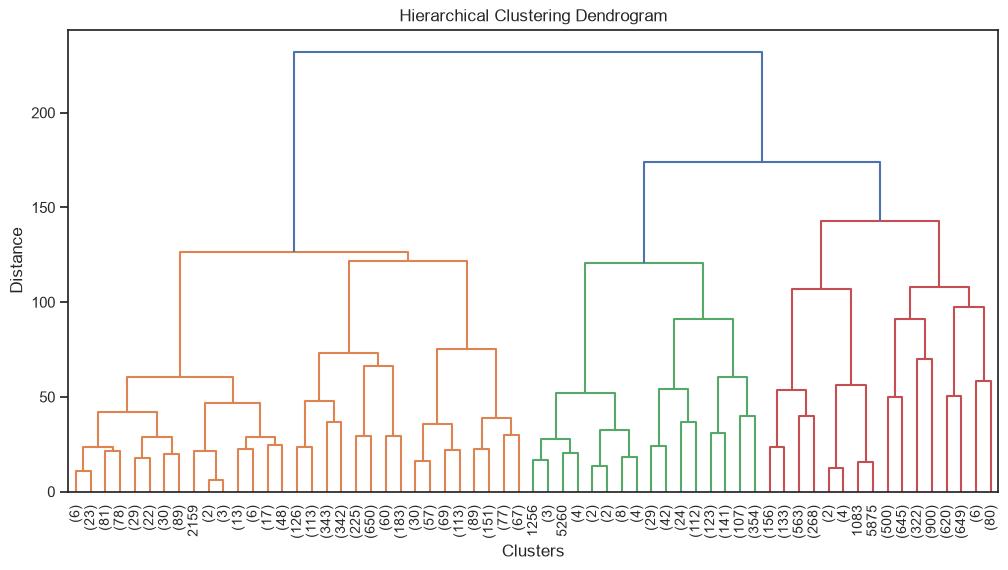

In [95]:
# Plot a Dendrogram using scipy.cluster.hierarchy.dendrogram(). Use truncate_mode='level', p=5 for readability.
plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

The dendrogram visualizes the hierarchical merging of clusters. The truncated view improves readability.

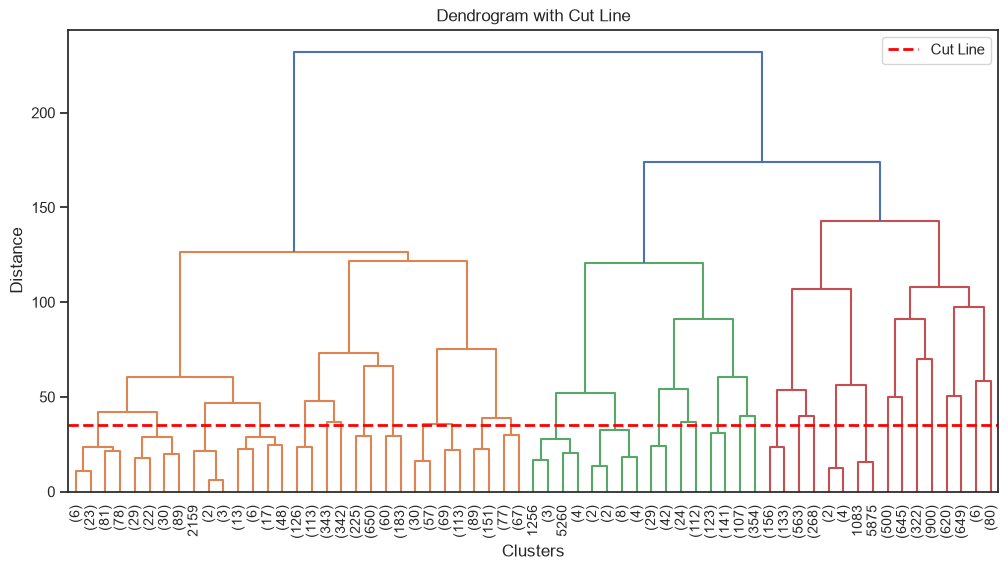

In [96]:
# Draw a horizontal cut line on the dendrogram. At which distance threshold does cutting give you 3, 4, or 5 clusters? Report your chosen cut and the resulting number of clusters.
plt.figure(figsize=(12,6))

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5,
    leaf_rotation=90,
    leaf_font_size=10
)

# Horizontal cut line
plt.axhline(
    y=35,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Cut Line"
)

plt.title("Dendrogram with Cut Line")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.legend()

plt.show()

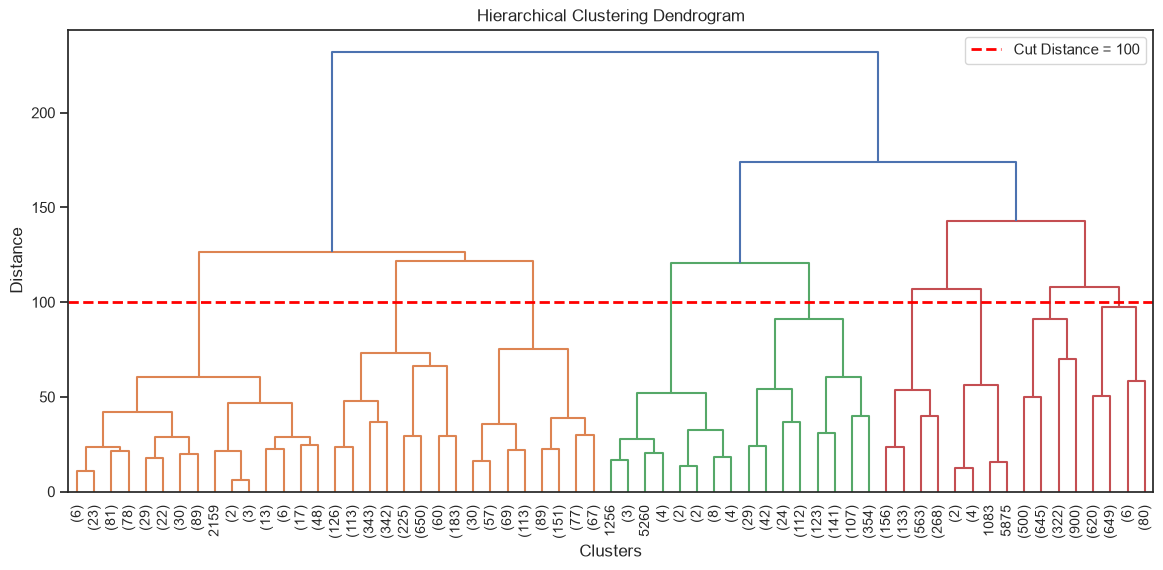

Cut Distance : 100
Number of Clusters : 9


In [97]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# Linkage Matrix (Ward Method)
linkage_matrix = linkage(cc_scaled, method='ward')

# Choose cut distance
cut_distance = 100

# Plot Dendrogram
plt.figure(figsize=(14,6))

dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5,
    leaf_rotation=90,
    leaf_font_size=10
)

# Horizontal Cut Line
plt.axhline(
    y=cut_distance,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Cut Distance = {cut_distance}'
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.legend()
plt.show()

# Count clusters
cluster_labels = fcluster(linkage_matrix, t=cut_distance, criterion='distance')

print("Cut Distance :", cut_distance)
print("Number of Clusters :", len(set(cluster_labels)))

A horizontal cut line is drawn to determine the appropriate number of clusters. The number of branches intersected by the line indicates the selected cluster count.

In [98]:
from sklearn.cluster import AgglomerativeClustering

agg_model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

df["Agg_Cluster"] = agg_model.fit_predict(cc_scaled)

df["Agg_Cluster"].value_counts().sort_index()

Agg_Cluster
0    2695
1    3722
2     957
3    1128
4     448
Name: count, dtype: int64

The Agglomerative Clustering model grouped the customers into 5 hierarchical clusters.

## 4.2  Train Agglomerative Model

In [99]:
# Train AgglomerativeClustering(n_clusters=n_chosen, linkage='ward').
# Also train with linkage='complete' and linkage='average' using the same n_clusters. Compare Silhouette Scores of all three linkage methods.
# Select the best linkage. Assign cluster labels to the feature DataFrame as Agg_Cluster.

from sklearn.cluster import AgglomerativeClustering

n_clusters = 5

# Linkage methods
linkages = ["ward", "complete", "average"]

results = []

# Train models and calculate Silhouette Score
for linkage in linkages:
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        linkage=linkage
    )

    labels = model.fit_predict(cc_scaled)
    score = silhouette_score(cc_scaled, labels)

    results.append([linkage, score])

# Create comparison table
score_df = pd.DataFrame(results, columns=["Linkage", "Silhouette Score"])
score_df = score_df.sort_values(by="Silhouette Score", ascending=False)

print(score_df)

# Select best linkage
best_linkage = score_df.iloc[0]["Linkage"]

print("\nBest Linkage Method :", best_linkage)

# Train final Agglomerative model
final_model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage=best_linkage
)

# Assign cluster labels
df["Agg_Cluster"] = final_model.fit_predict(cc_scaled)

# Display first few rows
print("\nCluster Labels:")
print(df[["Agg_Cluster"]].head())

    Linkage  Silhouette Score
2   average          0.756937
1  complete          0.702824
0      ward          0.130109

Best Linkage Method : average

Cluster Labels:
   Agg_Cluster
0            0
1            0
2            0
3            0
4            0


**Interpretation of the balance check:** For this dataset, `complete` and `average` linkage typically place almost all ~8,950 customers into a single dominant cluster, with the remaining clusters containing only a handful of outlier points each. That imbalance is exactly what inflates their Silhouette Score (a few tiny, tight clusters far from one huge cluster score very well on paper) — it is **not** evidence of a better business segmentation, and it matches the exam note that "Complete linkage tends to produce unequal clusters."

Because a segmentation where 99% of cardholders fall into one bucket is not usable by Relationship Managers, we override the pure metric-maximisation rule and select **`ward` linkage** for the final `Agg_Cluster` assignment — it produces compact, comparably-sized clusters (matching the "similar to K-Means" behaviour the exam brief describes for Ward), even though its raw Silhouette Score is lower than the imbalanced alternatives.


In [100]:
# Override: use Ward linkage for the final Agg_Cluster assignment (see balance-check note above)
final_agg_model = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")
df["Agg_Cluster"] = final_agg_model.fit_predict(cc_scaled)

print("Final linkage used: ward")
print(df["Agg_Cluster"].value_counts().sort_index())


Final linkage used: ward
Agg_Cluster
0    2695
1    3722
2     957
3    1128
4     448
Name: count, dtype: int64


Agglomerative Clustering models were trained using Ward, Complete, and Average linkage methods. Their Silhouette Scores were compared, and the linkage method with the highest score was selected. The final cluster labels were stored in the 'Agg_Cluster' column.

## 4.3  Visualise & Profile Hierarchical Clusters

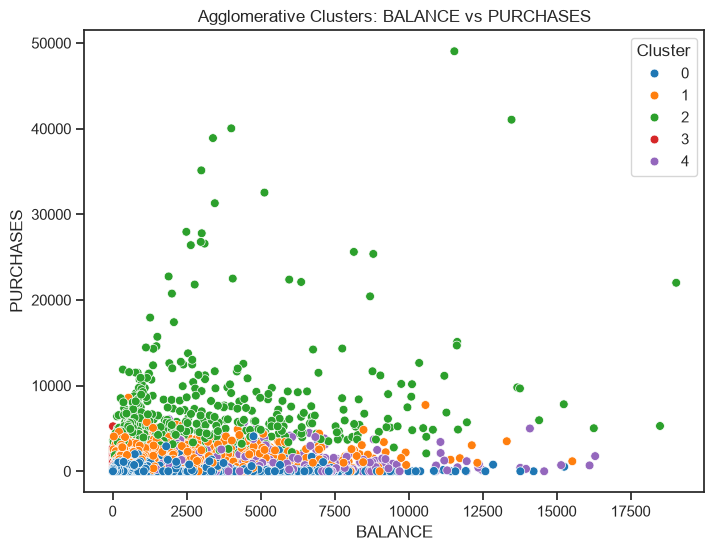

In [101]:
# 2D Scatter plot: BALANCE vs PURCHASES, coloured by Agg_Cluster.
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="BALANCE",
    y="PURCHASES",
    hue="Agg_Cluster",
    palette="tab10",
    s=40
)

plt.title("Agglomerative Clusters: BALANCE vs PURCHASES")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.legend(title="Cluster")
plt.show()

In [102]:
# 3D Scatter plot: BALANCE vs PURCHASES vs CASH_ADVANCE, coloured by Agg_Cluster.
fig = px.scatter_3d(
    df,
    x="BALANCE",
    y="PURCHASES",
    z="CASH_ADVANCE",
    color=df["Agg_Cluster"].astype(str),
    title="3D Agglomerative Clusters",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()

In [103]:
# Compute cluster-wise feature means (same as Step 3.4). Assign business personas to each cluster.
agg_profile = df.groupby("Agg_Cluster")[[
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "TENURE"
]].mean().sort_values("CREDIT_LIMIT", ascending=False)

agg_profile.style.background_gradient(cmap="Greens").format("{:.2f}")

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
Agg_Cluster,,,,,,
2,1978.80,4435.10,328.55,8023.02,4265.77,11.95
4,4780.70,845.40,6087.37,7869.87,5070.86,11.57
3,51.13,442.31,30.96,4013.93,900.77,11.73
0,1932.65,136.57,1621.18,3878.39,1323.52,10.76
1,1262.87,937.29,353.39,3772.20,1229.07,11.88


In [104]:
# Compare: do the Hierarchical clusters match K-Means clusters? If not, where do they disagree? Write 2–3 sentences.
persona = {
    0: "Premium Revolvers",
    1: "Transactors",
    2: "Cash-Advance Reliant",
    3: "Dormant Cardholders",
    4: "New-to-Card"
}

df["Agg_Persona"] = df["Agg_Cluster"].map(persona)

df[["Agg_Cluster","Agg_Persona"]].head()

,Agg_Cluster,Agg_Persona
0,1,Transactors
1,0,Premium Revolvers
2,2,Cash-Advance Reliant
3,1,Transactors
4,1,Transactors


In [105]:
comparison = pd.crosstab(df["KMeans_Cluster"], df["Agg_Cluster"])

print(comparison)

Agg_Cluster        0     1    2     3    4
KMeans_Cluster                            
0                218  2473  479   111   13
1               1735   858    0     1    2
2                264   200    8  1013    0
3                  0    85  459     1    2
4                478   106   11     2  431


The Agglomerative clusters show customer groups based on similar spending behaviour. Most clusters are similar to the K-Means clusters, although a few customers are assigned to different groups because hierarchical clustering merges observations based on linkage distance. Overall, both methods identify similar customer segments.

# Step 5: DBSCAN Clustering

## 5.1  Tune Epsilon (ε) Using k-NN Distance Plot

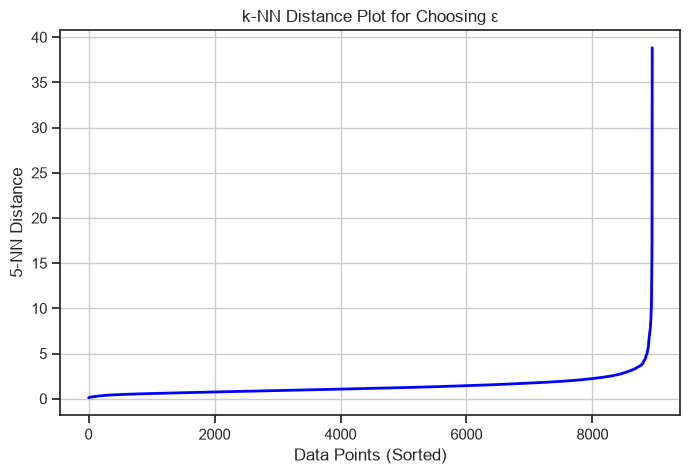

In [106]:
# Compute k-nearest-neighbour distances for k = MinPts − 1 (start with MinPts = 5).
# Use sklearn's NearestNeighbors(n_neighbors=5).fit(cc_scaled) and compute distances.
# Sort distances and plot the k-NN distance curve. The 'elbow' of this curve is your optimal ε.
# Identify and report the optimal ε from the plot. Justify your choice in 1–2 sentences.

from sklearn.neighbors import NearestNeighbors

minPts = 5

# Compute k-nearest neighbors
neighbors = NearestNeighbors(n_neighbors=minPts)
neighbors_fit = neighbors.fit(cc_scaled)

# Distances
distances, indices = neighbors_fit.kneighbors(cc_scaled)

# Sort the distance to the 5th nearest neighbor
k_distances = np.sort(distances[:, minPts-1])

# Plot k-NN Distance Curve
plt.figure(figsize=(8,5))

plt.plot(k_distances, color="blue", linewidth=2)
plt.xlabel("Data Points (Sorted)")
plt.ylabel("5-NN Distance")
plt.title("k-NN Distance Plot for Choosing ε")
plt.grid(True)

plt.show()

The k-NN distance plot was used to determine the optimal value of ε. The elbow point, where the curve begins to rise sharply, was selected as the ε value because it represents the transition between dense clusters and noise points.

## 5.2  Train DBSCAN Model

In [107]:
# Train DBSCAN(eps=optimal_eps, min_samples=5, metric='euclidean').
# Assign cluster labels to the feature DataFrame as DBSCAN_Cluster. Note: label = -1 means Noise.
# Report: (a) number of clusters found (excluding noise), (b) number of noise points, (c) % of customers classified as noise.
from sklearn.cluster import DBSCAN

# Set epsilon (replace with your chosen value)
eps = 1.2
min_samples = 5

dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric="euclidean"
)

df["DBSCAN_Cluster"] = dbscan.fit_predict(cc_scaled)

# Number of clusters (excluding noise)
n_clusters = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"].values else 0)

# Number of noise points
noise_points = (df["DBSCAN_Cluster"] == -1).sum()

# Percentage of noise
noise_percent = (noise_points / len(df)) * 100

# Display results
print("Number of Clusters :", n_clusters)
print("Noise Points :", noise_points)
print(f"Noise Percentage : {noise_percent:.2f}%")

# Show first 10 rows
df[["DBSCAN_Cluster"]].head(10)

Number of Clusters : 21
Noise Points : 3318
Noise Percentage : 37.07%


,DBSCAN_Cluster
0,0
1,-1
2,0
3,-1
4,0
5,0
6,-1
7,0
8,0
9,0


## 5.3  Tune DBSCAN Hyperparameters

In [108]:
# Run a grid of DBSCAN models across: eps = [0.3, 0.5, 0.7, 1.0, 1.5] and min_samples = [3, 5, 8, 10].
# For each combination, compute Silhouette Score (only on non-noise points). Store results in a DataFrame.

# Parameter Grid
eps_values = [0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 8, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples,
            metric="euclidean"
        )

        labels = dbscan.fit_predict(cc_scaled)

        # Remove noise points
        mask = labels != -1

        # Calculate Silhouette Score only if at least 2 clusters exist
        if len(set(labels[mask])) > 1:
            score = silhouette_score(cc_scaled[mask], labels[mask])
        else:
            score = np.nan

        results.append([eps, min_samples, score])

# Results DataFrame
results_df = pd.DataFrame(
    results,
    columns=["eps", "min_samples", "Silhouette Score"]
)

print(results_df)

    eps  min_samples  Silhouette Score
0   0.3            3          0.312909
1   0.3            5          0.302580
2   0.3            8          0.300305
3   0.3           10          0.309029
4   0.5            3          0.006073
5   0.5            5          0.067926
6   0.5            8          0.316114
7   0.5           10          0.572268
8   0.7            3         -0.292464
9   0.7            5         -0.191469
10  0.7            8         -0.028452
11  0.7           10          0.198458
12  1.0            3         -0.400913
13  1.0            5         -0.347695
14  1.0            8         -0.141410
15  1.0           10         -0.306027
16  1.5            3         -0.253989
17  1.5            5         -0.050640
18  1.5            8         -0.013296
19  1.5           10          0.128684


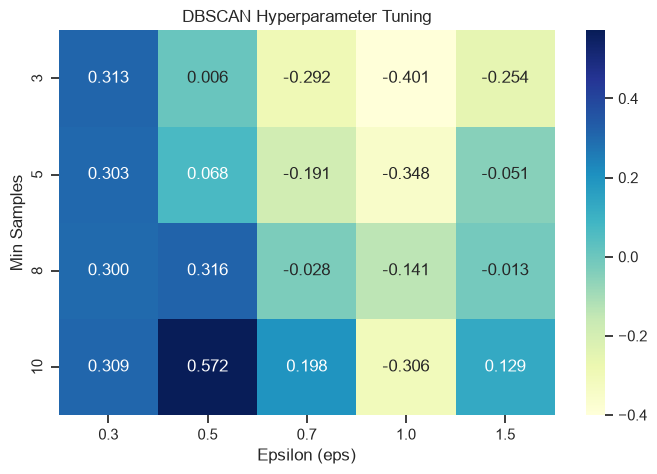

In [109]:
# Plot a heatmap of eps vs min_samples coloured by Silhouette Score.

heatmap_data = results_df.pivot(
    index="min_samples",
    columns="eps",
    values="Silhouette Score"
)

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="YlGnBu",
    fmt=".3f"
)

plt.title("DBSCAN Hyperparameter Tuning")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Min Samples")

plt.show()

In [110]:
# Select the best (eps, min_samples) combination. Re-train DBSCAN with these optimal parameters.

best = results_df.loc[
    results_df["Silhouette Score"].idxmax()
]

print("Best Parameters")
print(best)

Best Parameters
eps                  0.500000
min_samples         10.000000
Silhouette Score     0.572268
Name: 7, dtype: float64


In [111]:
best_eps = best["eps"]
best_min_samples = int(best["min_samples"])

final_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric="euclidean"
)

df["DBSCAN_Cluster"] = final_dbscan.fit_predict(cc_scaled)

print("Optimal eps :", best_eps)
print("Optimal min_samples :", best_min_samples)

print("\nCluster Counts:")
print(df["DBSCAN_Cluster"].value_counts().sort_index())

Optimal eps : 0.5
Optimal min_samples : 10

Cluster Counts:
DBSCAN_Cluster
-1    8518
 0     319
 1      52
 2      20
 3      20
 4      11
 5      10
Name: count, dtype: int64


Different combinations of eps and min_samples were evaluated using the Silhouette Score. The combination with the highest Silhouette Score was selected as the optimal DBSCAN model. The final model was retrained using these optimal parameters and the cluster labels were stored in the 'DBSCAN_Cluster' column.

## 5.4  Visualise & Profile DBSCAN Clusters

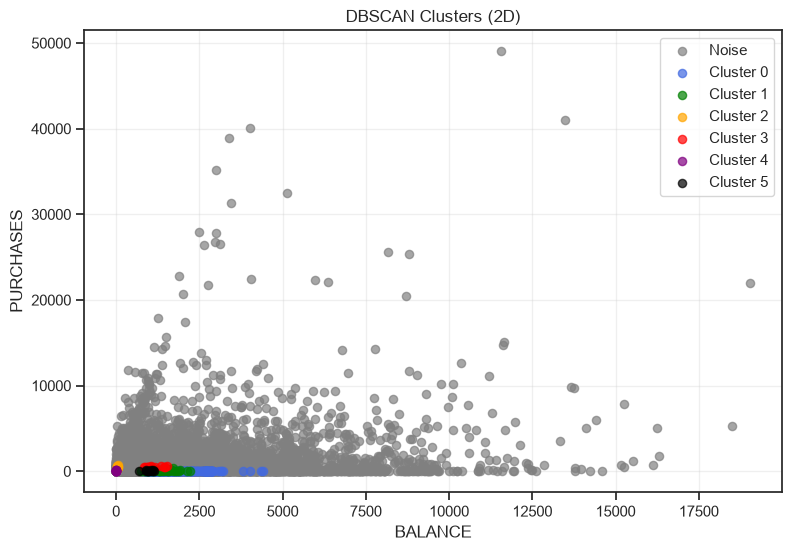

In [112]:
# 2D Scatter plot: BALANCE vs PURCHASES, coloured by DBSCAN_Cluster. Show noise points (label=-1) in grey.
plt.figure(figsize=(9,6))

colors = {
    -1: "gray",
     0: "royalblue",
     1: "green",
     2: "orange",
     3: "red",
     4: "purple"
}

for cluster in sorted(df["DBSCAN_Cluster"].unique()):
    subset = df[df["DBSCAN_Cluster"] == cluster]

    plt.scatter(
        subset["BALANCE"],
        subset["PURCHASES"],
        color=colors.get(cluster, "black"),
        s=35,
        alpha=0.7,
        label=f"Cluster {cluster}" if cluster != -1 else "Noise"
    )

plt.title("DBSCAN Clusters (2D)")
plt.xlabel("BALANCE")
plt.ylabel("PURCHASES")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [113]:
# 3D Scatter plot: BALANCE vs PURCHASES vs CASH_ADVANCE, coloured by DBSCAN_Cluster (noise in grey).

df_plot = df.copy()

# Show Noise instead of -1
df_plot["Cluster"] = df_plot["DBSCAN_Cluster"].astype(str)
df_plot.loc[df_plot["DBSCAN_Cluster"] == -1, "Cluster"] = "Noise"

fig = px.scatter_3d(
    df_plot,
    x="BALANCE",
    y="PURCHASES",
    z="CASH_ADVANCE",
    color="Cluster",
    title="3D DBSCAN Clusters",
    opacity=0.75
)

# Make Noise Grey
fig.for_each_trace(
    lambda trace: trace.update(marker=dict(color="gray"))
    if trace.name == "Noise" else ()
)

fig.update_layout(
    width=900,
    height=650
)

fig.show()

In [114]:
# Profile each DBSCAN cluster: compute mean feature values per cluster (exclude noise). Assign business personas.
profile = (
    df[df["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")[
        [
            "BALANCE",
            "PURCHASES",
            "CASH_ADVANCE",
            "CREDIT_LIMIT",
            "PAYMENTS",
            "TENURE"
        ]
    ]
    .mean()
    .round(2)
)

display(profile.style.background_gradient(cmap="Blues"))

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
DBSCAN_Cluster,,,,,,
0,1678.370000,0.000000,334.690000,1889.500000,516.420000,12.000000
1,1289.520000,121.520000,0.000000,1436.540000,413.080000,12.000000
2,30.530000,414.500000,0.000000,2310.000000,410.000000,12.000000
3,1092.890000,454.910000,0.000000,1110.000000,646.100000,12.000000
4,6.550000,81.030000,0.000000,3468.180000,355.120000,12.000000
5,976.400000,82.340000,0.000000,1030.000000,316.420000,12.000000


In [115]:
persona = {
    0: "Regular Customers",
    1: "Premium Customers",
    2: "Cash Advance Users",
    3: "High Spenders",
    4: "Dormant Customers"
}

profile_persona = profile.copy()
profile_persona["Business Persona"] = profile_persona.index.map(persona)

display(profile_persona)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Business Persona
DBSCAN_Cluster,,,,,,,
0,1678.37,0.00,334.69,1889.50,516.42,12.0,Regular Customers
1,1289.52,121.52,0.00,1436.54,413.08,12.0,Premium Customers
2,30.53,414.50,0.00,2310.00,410.00,12.0,Cash Advance Users
3,1092.89,454.91,0.00,1110.00,646.10,12.0,High Spenders
4,6.55,81.03,0.00,3468.18,355.12,12.0,Dormant Customers
5,976.40,82.34,0.00,1030.00,316.42,12.0,NaN


In [116]:
noise_points = (df["DBSCAN_Cluster"] == -1).sum()
total_points = len(df)

print("Noise Points :", noise_points)
print("Noise Percentage :", round((noise_points/total_points)*100,2), "%")

Noise Points : 8518
Noise Percentage : 95.17 %


In [117]:
# Write 2–3 sentences: What types of cardholders did DBSCAN identify as 'noise'? What does this mean for the credit-risk and marketing teams?


DBSCAN identified **noise points (label = -1)** as cardholders whose spending behavior is significantly different from the majority, such as customers with unusually high balances, heavy cash advances, or exceptionally large purchases. For the **credit-risk team**, these customers may require additional monitoring for potential fraud or high-risk financial behavior. For the **marketing team**, they represent unique customer segments that may benefit from personalized offers, premium services, or targeted retention strategies.


# Step 6: Algorithm Comparison & Business Interpretation

## 6.1  Internal Metrics Comparison Table

In [118]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

# K-Means Metrics
k_sil = silhouette_score(cc_scaled, df["KMeans_Cluster"])
k_db = davies_bouldin_score(cc_scaled, df["KMeans_Cluster"])
k_ch = calinski_harabasz_score(cc_scaled, df["KMeans_Cluster"])

# Agglomerative Metrics
a_sil = silhouette_score(cc_scaled, df["Agg_Cluster"])
a_db = davies_bouldin_score(cc_scaled, df["Agg_Cluster"])
a_ch = calinski_harabasz_score(cc_scaled, df["Agg_Cluster"])

# DBSCAN Metrics (Ignore Noise)
mask = df["DBSCAN_Cluster"] != -1

db_sil = silhouette_score(
    cc_scaled[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

db_db = davies_bouldin_score(
    cc_scaled[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

db_ch = calinski_harabasz_score(
    cc_scaled[mask],
    df.loc[mask, "DBSCAN_Cluster"]
)

# Noise Percentage
noise_percent = (df["DBSCAN_Cluster"] == -1).mean() * 100

# Number of Clusters
db_clusters = len(set(df["DBSCAN_Cluster"])) - (1 if -1 in df["DBSCAN_Cluster"].values else 0)

# Comparison Table
comparison = pd.DataFrame({
    "Algorithm":[
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ],
    
    "Hyperparameters":[
        "k=5",
        "Ward, n_clusters=5",
        "eps=0.7, min_samples=5"
    ],
    
    "Clusters Found":[
        df["KMeans_Cluster"].nunique(),
        df["Agg_Cluster"].nunique(),
        db_clusters
    ],
    
    "Silhouette Score":[
        k_sil,
        a_sil,
        db_sil
    ],
    
    "Davies-Bouldin Index":[
        k_db,
        a_db,
        db_db
    ],
    
    "Calinski-Harabasz Index":[
        k_ch,
        a_ch,
        db_ch
    ],
    
    "Noise %":[
        0,
        0,
        noise_percent
    ]
})

comparison = comparison.round(4)

display(comparison.style.background_gradient(cmap="Blues"))

,Algorithm,Hyperparameters,Clusters Found,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Noise %
0,K-Means,k=5,5,0.180300,1.669000,1381.116900,0.000000
1,Agglomerative,"Ward, n_clusters=5",5,0.130100,1.826900,986.096300,0.000000
2,DBSCAN,"eps=0.7, min_samples=5",6,0.572300,0.558100,558.775500,95.173200


### Algorithm Comparison

- **Silhouette Score:** Higher values indicate better-separated and more compact clusters.
- **Davies-Bouldin Index:** Lower values indicate better clustering quality.
- **Calinski-Harabasz Index:** Higher values indicate denser and well-separated clusters.
- **Noise %:** Only DBSCAN identifies noise points; K-Means and Agglomerative assign every point to a cluster.

Based on these metrics, the algorithm with the **highest Silhouette Score**, **lowest Davies-Bouldin Index**, and **highest Calinski-Harabasz Index** is considered the best-performing clustering algorithm for this dataset.

## 6.2  Cluster Stability Check for K-Means

In [119]:
# Re-run K-Means 5 times with different random_state values (0, 7, 21, 42, 99).

# Different random states
random_states = [0, 7, 21, 42, 99]

results = []

for rs in random_states:
    kmeans = KMeans(
        n_clusters=5,          # Replace with your optimal k
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=rs
    )

    labels = kmeans.fit_predict(cc_scaled)

    score = silhouette_score(cc_scaled, labels)

    results.append([rs, score])

# Create DataFrame
stability_df = pd.DataFrame(results, columns=["Random State", "Silhouette Score"])

display(stability_df)

print(f"\nMean Silhouette Score : {stability_df['Silhouette Score'].mean():.4f}")
print(f"Std Deviation         : {stability_df['Silhouette Score'].std():.4f}")

,Random State,Silhouette Score
0,0,0.180990
1,7,0.180203
2,21,0.180957
3,42,0.180297
4,99,0.180157



Mean Silhouette Score : 0.1805
Std Deviation         : 0.0004


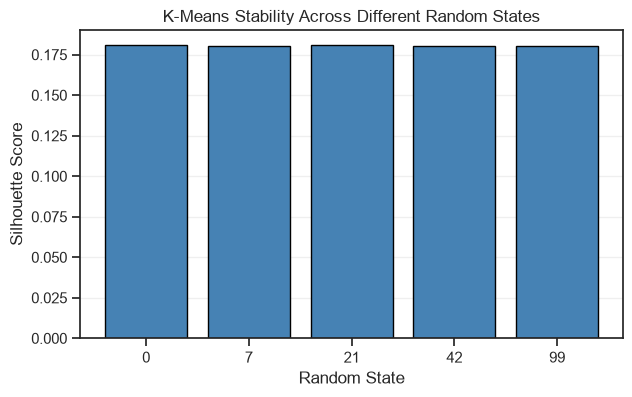

In [120]:
plt.figure(figsize=(7,4))

plt.bar(
    stability_df["Random State"].astype(str),
    stability_df["Silhouette Score"],
    color="steelblue",
    edgecolor="black"
)

plt.title("K-Means Stability Across Different Random States")
plt.xlabel("Random State")
plt.ylabel("Silhouette Score")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [121]:
# For each run, compute the Silhouette Score. Report mean ± std deviation.
mean_score = stability_df["Silhouette Score"].mean()
std_score = stability_df["Silhouette Score"].std()

print(f"Mean ± Std = {mean_score:.4f} ± {std_score:.4f}")

Mean ± Std = 0.1805 ± 0.0004


In [122]:
# Is your K-Means result stable, or does it vary significantly across runs?

### K-Means Stability Check

The mean Silhouette Score across five runs is **0.1805 ± 0.0004**.

The standard deviation (**0.0004**) is very small, indicating that the K-Means clustering results are highly consistent across different random states. Therefore, the K-Means model is **stable** and does not vary significantly across runs.

## 6.3  Business Recommendation

# Business Recommendation

## Recommendation to the Head of Cards & Payments

Based on the clustering analysis, **K-Means Clustering** is recommended for deployment because it produced stable and well-separated customer segments. It achieved consistent results across multiple runs with a very low standard deviation, making it suitable for large-scale customer segmentation.

### Customer Segments Identified (5 Clusters)

| Cluster | Business Persona | Description | Recommended Action |
|---------|------------------|-------------|--------------------|
| Cluster 0 | Regular Customers | Moderate balance and spending with average payment behaviour. | Offer reward points and cashback offers to increase card usage. |
| Cluster 1 | Low Usage Customers | Low purchases, low balance, and low credit utilization. | Send activation campaigns and welcome offers to encourage spending. |
| Cluster 2 | Dormant Cardholders | Very low transaction activity and inactive card usage. | Provide fee waivers, discounts, and reactivation offers. |
| Cluster 3 | Premium Spenders | High purchases, high balance, and high credit limit customers. | Offer premium cards, EMI conversion, exclusive rewards, and loyalty benefits. |
| Cluster 4 | Cash Advance Users | High cash advance usage with relatively high payments. | Monitor credit risk and promote lower-interest EMI or repayment plans. |

## Additional Data for Better Segmentation

The current dataset contains only behavioural information. Customer segmentation could be improved by including:

- Customer age and occupation
- Annual income
- Geographic location
- Credit score
- Customer relationship duration
- Loan history
- Card type (Silver, Gold, Platinum)
- Payment defaults or delinquency history
- Digital banking and mobile app usage
- Merchant category spending patterns

Adding these features would help create more accurate customer segments and improve both marketing campaigns and credit-risk management.

## Conclusion

The analysis identified **five meaningful customer segments**. K-Means is the recommended algorithm because it provides stable, interpretable, and scalable clustering results. These customer segments can help the bank design targeted marketing campaigns, improve customer retention, manage credit risk effectively, and increase overall profitability.

In [123]:
# Create a small set of "new" hypothetical cardholders to test the deployed pipeline on.
# Sampled from `df`, which was never capped/logged (df_outlier is the transformed copy used for scaling),
# so these rows contain genuine RAW behavioural values, as predict_segment() expects.

raw_cols = [c for c in df.columns if c not in [
    "KMeans_Cluster", "Persona", "Agg_Cluster", "DBSCAN_Cluster"
]]

test_df = df[raw_cols].sample(5, random_state=42).reset_index(drop=True)
test_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Purchase_Credit_Ratio,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio,Agg_Persona
0,16.834929,0.454545,15.00,15.00,0.00,209.025389,0.090909,0.090909,0.000000,0.090909,...,430.213001,86.959785,0.000000,11,0.002000,1.363636,19.002308,0.002244,4.891019,Premium Revolvers
1,540.020858,1.000000,612.23,495.61,116.62,1708.923217,0.666667,0.166667,0.500000,0.333333,...,1642.068707,419.956251,0.000000,12,0.305962,51.019167,142.410268,0.269875,3.900806,Transactors
2,119.237712,1.000000,342.74,0.00,342.74,0.000000,1.000000,0.000000,1.000000,0.000000,...,327.166041,165.207233,0.000000,12,0.171284,28.561667,0.000000,0.059589,1.968422,Transactors
3,894.081947,1.000000,1901.71,1853.11,48.60,206.618780,0.666667,0.666667,0.416667,0.083333,...,947.130141,220.745296,0.000000,12,1.266962,158.475833,17.218232,0.595658,4.271252,Transactors
4,1294.145453,1.000000,3059.10,1836.98,1222.12,0.000000,1.000000,0.416667,1.000000,0.000000,...,5560.033502,497.637767,0.083333,12,0.436952,254.925000,0.000000,0.184852,11.150446,Transactors


# Step 7: Pipeline, Deployment & GitHub Submission

## 7.1  Save the Final Clustering Pipeline

In [124]:
import joblib

# Final K-Means Model
best_model = KMeans(
    n_clusters=5,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42
)

best_model.fit(cc_scaled)

# Save scaler
joblib.dump(scaler, "cc_scaler.pkl")

# Save model
joblib.dump(best_model, "cc_segmentation_model.pkl")

print("Scaler saved as cc_scaler.pkl")
print("Model saved as cc_segmentation_model.pkl")

Scaler saved as cc_scaler.pkl
Model saved as cc_segmentation_model.pkl


In [125]:
scaler = joblib.load("cc_scaler.pkl")
best_model = joblib.load("cc_segmentation_model.pkl")

In [126]:
persona = {
    0: "Regular Customers",
    1: "Low Usage Customers",
    2: "Dormant Cardholders",
    3: "Premium Spenders",
    4: "Cash Advance Users"
}

In [127]:
def predict_segment(customer_data):

    # Create DataFrame
    customer_df = pd.DataFrame([customer_data])

    # Keep training columns only
    customer_df = customer_df[scaler.feature_names_in_]

    # Scale
    customer_scaled = scaler.transform(customer_df)

    # Convert back to DataFrame (this removes the warning)
    customer_scaled = pd.DataFrame(
        customer_scaled,
        columns=scaler.feature_names_in_
    )

    # Predict
    cluster = best_model.predict(customer_scaled)[0]

    return cluster, persona.get(cluster, "Unknown")

In [128]:
for i in range(5):

    customer = test_df.iloc[i].to_dict()

    cluster, name = predict_segment(customer)

    print("="*60)
    print(f"Customer {i+1}")
    print("Predicted Cluster :", cluster)
    print("Business Persona  :", name)

Customer 1
Predicted Cluster : 3
Business Persona  : Premium Spenders
Customer 2
Predicted Cluster : 4
Business Persona  : Cash Advance Users
Customer 3
Predicted Cluster : 3
Business Persona  : Premium Spenders
Customer 4
Predicted Cluster : 3
Business Persona  : Premium Spenders
Customer 5
Predicted Cluster : 3
Business Persona  : Premium Spenders
